**The Confusion Matrix and Basic Metrics**
- **Dataset:** from sklearn.datasets import load_breast_cancer
- **Task:** Take the predictions from any of your intermediate models above.
- **Action:** Generate a Confusion Matrix. From the matrix values, manually calculate the Accuracy, Precision, Recall, and F1-Score using Python math, and then verify your answers using sklearn.metrics.classification_report.

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load Dataset and Split
data = load_breast_cancer()
X, y = data.data, data.target

# Note: In this dataset, 0 = Malignant (Negative), 1 = Benign (Positive)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train an Intermediate Model & Get Predictions
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Generate Confusion Matrix
# sklearn matrix layout: 
# [ [TN, FP],
#   [FN, TP] ]
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("--- Confusion Matrix ---")
print(cm)
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}\n")

# 4. Manual Calculations using Python Math
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("--- Manually Calculated Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}\n")

# 5. Verification using classification_report
print("--- Sklearn Verification Report ---")
print(classification_report(y_test, y_pred, target_names=data.target_names, digits=4))

--- Confusion Matrix ---
[[ 61   2]
 [  2 106]]
TN: 61, FP: 2, FN: 2, TP: 106

--- Manually Calculated Metrics ---
Accuracy:  0.9766
Precision: 0.9815
Recall:    0.9815
F1-Score:  0.9815

--- Sklearn Verification Report ---
              precision    recall  f1-score   support

   malignant     0.9683    0.9683    0.9683        63
      benign     0.9815    0.9815    0.9815       108

    accuracy                         0.9766       171
   macro avg     0.9749    0.9749    0.9749       171
weighted avg     0.9766    0.9766    0.9766       171



**The ROC Curve and AUC**
- **Dataset:** from sklearn.datasets import load_breast_cancer
- **Task:** Train a classifier that outputs probabilities (like Logistic Regression or Random Forest) on a binary classification dataset.
- **Action:** Extract the predicted probabilities (predict_proba) rather than the absolute class predictions. Use these probabilities to plot a Receiver Operating Characteristic (ROC) curve. Calculate and display the Area Under the Curve (AUC) score on the plot. Explain what the curve represents regarding True Positive vs. False Positive trade-offs.

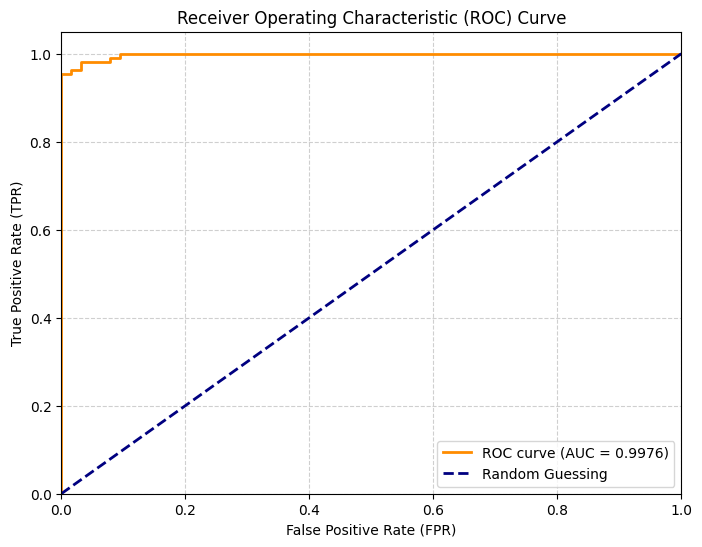

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Load Dataset and Split
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train a Classifier that outputs probabilities
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# 3. Extract predicted probabilities for the positive class (column 1)
y_probs = model.predict_proba(X_test)[:, 1]

# 4. Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 5. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()